# Homework 2

**Course:** MATH 6388

**Author:** Brady Lamson

**Date:** 8/28/2026

---

## Imports

In [43]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

## Problem 1.3

In the implementation of `UnivariateLinearRegression`, locate the following two lines inside the `fit()` method:

`self.w0.grad.zero_()`
`self.w1.grad.zero_()`

Comment out (or remove) these two lines and run the same training example from the notebook. Plot or record the training loss over the epochs. Explain why the optimization behaves differently.

### Notes

Most of the code presented here is the same. The key differences are that I store the loss in a list in the `UnivariateLinearRegression` class and then modify the plot to show the loss over each epoch. I include a parameter in `.fit(reset_gradients=True)` so I can easily re-use this on later problems with the correct implementation.

In [44]:
class UnivariateLinearRegression:
    def __init__(self, learning_rate=0.01, num_epochs=1000):
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs

        # Initialize parameters randomly
        self.w0 = torch.randn(1, requires_grad=True)
        self.w1 = torch.randn(1, requires_grad=True)

        # Track the loss for later as a simple list
        self.loss = []

    def fit(self, x, y, reset_gradients=True):
        x = torch.as_tensor(x, dtype=torch.float32)
        y = torch.as_tensor(y, dtype=torch.float32)

        for epoch in range(self.num_epochs):

            # Forward pass
            y_hat = self.w0 + self.w1 * x

            # Compute MSE loss
            loss = torch.mean((y_hat - y) ** 2)
            # Save the loss
            self.loss.append(loss.item())

            # Compute gradients
            loss.backward()

            # Gradient descent update
            with torch.no_grad():
                self.w0 -= self.learning_rate * self.w0.grad
                self.w1 -= self.learning_rate * self.w1.grad

            if reset_gradients:
                self.w0.grad.zero_()
                self.w1.grad.zero_()

            if epoch % 100 == 0:
                print(f"Epoch {epoch:4d} | Loss = {loss.item():.4f}")

    def predict(self, x):
        x = torch.as_tensor(x, dtype=torch.float32)

        with torch.no_grad():
            return self.w0 + self.w1 * x

In [45]:
# For reproducibility
torch.manual_seed(42)

# Generate inputs
# Brady notes: Create a tensor of length 50 that moves from 0 to 10 in identically spaced increments
x = torch.linspace(0, 10, 50)

# True parameters
w0_true = 3.0
w1_true = 2.0

# Generate targets with a small amount of Gaussian noise
y = w0_true + w1_true * x + 0.5 * torch.randn_like(x)

In [46]:
model = UnivariateLinearRegression(
    learning_rate=0.01,
    num_epochs=1000
)

print(f"Initial w0 = {model.w0.item():.3f}")
print(f"Initial w1 = {model.w1.item():.3f}")

model.fit(x, y, reset_gradients=False)

print(f"Estimated w0 = {model.w0.item():.3f}")
print(f"Estimated w1 = {model.w1.item():.3f}")

print(f"True w0 = {w0_true}")
print(f"True w1 = {w1_true}")

Initial w0 = -0.569
Initial w1 = 1.258
Epoch    0 | Loss = 58.6934
Epoch  100 | Loss = 12.1492
Epoch  200 | Loss = 7.1529
Epoch  300 | Loss = 53.1076
Epoch  400 | Loss = 66.8319
Epoch  500 | Loss = 23.3234
Epoch  600 | Loss = 1.4133
Epoch  700 | Loss = 40.7238
Epoch  800 | Loss = 69.9317
Epoch  900 | Loss = 36.3944
Estimated w0 = 4.237
Estimated w1 = 1.706
True w0 = 3.0
True w1 = 2.0


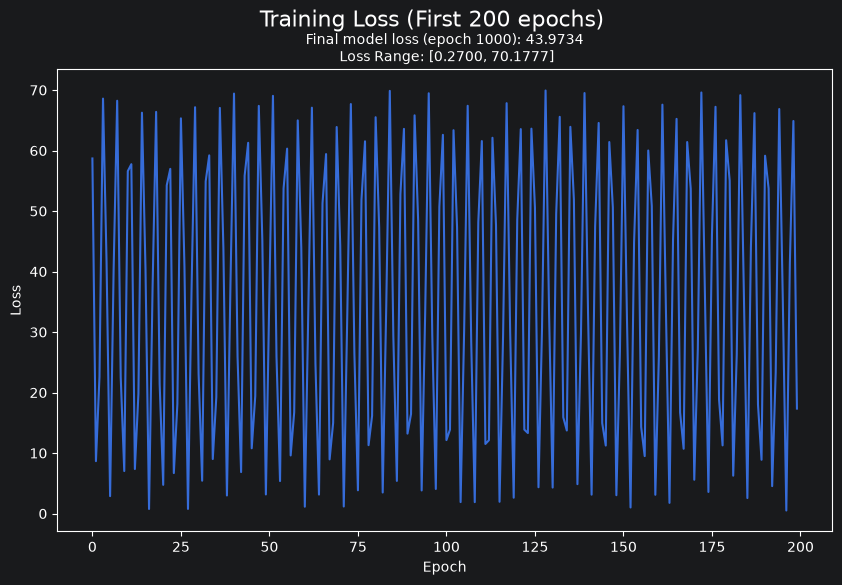

In [47]:
loss = torch.FloatTensor(model.loss)
index = torch.linspace(0, len(model.loss) - 1, len(model.loss))
plt.figure(figsize=(10,6))
epochs = 200
# Only show the first n epochs as the plot becomes illegible for all 1000 epochs
plt.plot(index[:epochs], loss[:epochs])
plt.suptitle(f"Training Loss (First {epochs} epochs)", fontsize=16)
plt.title(f"Final model loss (epoch 1000): {loss[-1]:.4f}\n Loss Range: [{min(loss):.4f}, {max(loss):.4f}]", fontsize=10)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

### Explanation

We can see that the optimization behaves differently in that it no longer optimizes at all. What we see now is the loss wildly swinging back and forth. It gets really low and then shoots back up over and over again. This is happening because the gradients aren't reset between epochs. The gradients function as our navigational tool across the function we're optimizing. Their values tell us how to adjust our weights to continue to improve the loss based on what the parameter values are **right now**. Failing to reset them muddies that information as the gradient value is now an accumulation of all previous epochs. That meaningful information is drowned out, so worse decisions are made on updating the weights, resulting in the erratic loss scores observed above.

## Problem 1.4

In this problem, you will apply your implementation of gradient descent to a real-world dataset. Use the correct implementation of the `UnivariateLinearRegression` class from the previous section (the version that correctly calls `zero_()` to clear the gradients after each parameter update).

Use the Credit dataset provided with this notebook.

- Input feature: Rating
- Target variable: Balance

Train your UnivariateLinearRegression model using the training data. Use the trained model to predict the balances for the testing data. Create a scatter plot comparing the actual and predicted balance values on the testing set.

- The x-axis labeled Actual Balance.
- The y-axis labeled Predicted Balance.
- A scatter plot of the test samples.
- A 45-degree reference line (i.e., (y=x)) to indicate perfect predictions.

### NOTE

I had to use a quick-fix found on stackoverflow due to an error I had trying to pull from the online csv. I'm using these notebooks locally so I'm not sure what is causing this behavior.

In [48]:
# Code I copied to fix a 'ssl-certificate-verify-failed' error -Brady
# Source - https://stackoverflow.com/a/49174340
# Posted by Jia, modified by community. See post 'Timeline' for change history
# Retrieved 2026-08-18, License - CC BY-SA 4.0
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

url = "https://raw.githubusercontent.com/farhad-pourkamali/MATH6388Updated/refs/heads/main/Data/Credit.csv"
data = pd.read_csv(url, index_col=0)
print("Data ---\n", data.head(), "\n")

# 1. Extract raw numpy arrays
x_train_raw = data["Rating"][:200].to_numpy()
x_test_raw  = data["Rating"][200:].to_numpy()

y_train = data["Balance"][:200].to_numpy()
y_test  = data["Balance"][200:].to_numpy()

# 2. Normalize X features using training set parameters
# (This scales X values to a manageable 0 to 1 range)
x_min = x_train_raw.min()
x_max = x_train_raw.max()

x_train = (x_train_raw - x_min) / (x_max - x_min)
x_test  = (x_test_raw - x_min) / (x_max - x_min)

# 3. Train the model
model = UnivariateLinearRegression(
    learning_rate=0.01,
    num_epochs=1000
)

print(f"Initial w0 = {model.w0.item():.3f}")
print(f"Initial w1 = {model.w1.item():.3f}")

model.fit(x_train, y_train, reset_gradients=True)
print(f"Estimated w0 = {model.w0.item():.3f}")
print(f"Estimated w1 = {model.w1.item():.3f}")

y_pred = model.predict(x_test)

Data ---
     Income  Limit  Rating  Cards  Age  Education  Gender Student Married  \
1   14.891   3606     283      2   34         11    Male      No     Yes   
2  106.025   6645     483      3   82         15  Female     Yes     Yes   
3  104.593   7075     514      4   71         11    Male      No      No   
4  148.924   9504     681      3   36         11  Female      No      No   
5   55.882   4897     357      2   68         16    Male      No     Yes   

   Ethnicity  Balance  
1  Caucasian      333  
2      Asian      903  
3      Asian      580  
4      Asian      964  
5  Caucasian      331   

Initial w0 = -1.589
Initial w1 = -1.121
Epoch    0 | Loss = 491171.7188
Epoch  100 | Loss = 191311.2656
Epoch  200 | Loss = 171894.4062
Epoch  300 | Loss = 157837.3438
Epoch  400 | Loss = 145477.7656
Epoch  500 | Loss = 134577.4375
Epoch  600 | Loss = 124963.6016
Epoch  700 | Loss = 116484.4375
Epoch  800 | Loss = 109006.0000
Epoch  900 | Loss = 102410.1875
Estimated w0 = 201.809
Esti

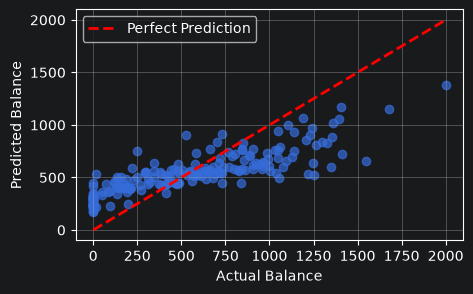

In [49]:
plt.figure(figsize=(5, 3))

# Scatter plot
plt.scatter(y_test, y_pred, alpha=0.7)

# 45-degree reference line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val],
         [min_val, max_val],
         'r--',
         linewidth=2,
         label='Perfect Prediction')

plt.xlabel("Actual Balance")
plt.ylabel("Predicted Balance")
plt.legend()
plt.grid(True)

plt.show()

## Problem 1.5

One of the most useful methods in PyTorch is `.detach()`, which creates a new tensor that shares the same numerical values as the original tensor but is detached from the computation graph. In other words, PyTorch treats the detached tensor as a constant during backpropagation, so gradients are not propagated through the operations that produced it.

In this problem, you will investigate how .detach() affects both the computation graph and the gradients computed by PyTorch.

Let

$$
z = \log(w)
$$

and define the loss function

$$
L = w^2 z.
$$

Assume

```
w = torch.tensor(2.0, requires_grad=True)
```

Part A: Without .detach()

Consider the following code:

```
import torch

w = torch.tensor(2.0, requires_grad=True)

z = torch.log(w)
loss = w**2 * z

loss.backward()
```

Compute $\frac{dL}{dw}$ by hand and run the code and verify that the gradient matches your calculation.

Part B: With .detach()

Now modify the code as follows:

```
import torch

w = torch.tensor(2.0, requires_grad=True)

z = torch.log(w).detach()
loss = w**2 * z

loss.backward()
```
Compute $\frac{dL}{dw}$ by hand and run the code and compare the gradient with your prediction.


### Part A

Let's start with the manual work.

$$
\begin{align}
    z &= \ln{w} \\
    L &= w^2 \cdot z \\
    \frac{dL}{dw} &= \frac{d}{dw} w^2 z \\
    &= \frac{d}{dw} w^2 \ln{w} & \text{(Substitution)} \\
    &= \left( \frac{d}{dw} w^2 \right) \ln{w} + w^2 \left( \frac{d}{dw} \ln{w} \right) & \text{(Product rule)} \\
    &= 2w\ln{w} + w^2 \cdot \frac{1}{w} \\
    &= 2w\ln{w} + w
\end{align}
$$

Now, we let $w = 2$.

$$
\begin{align}
    \frac{dL}{dw} &= 2 \cdot 2 \ln(2) + 2 \\
    &\approx 4.773
\end{align}
$$

In [50]:
# Show calculation
import math
4 * math.log(2) + 2

4.772588722239782

In [51]:
w = torch.tensor(2.0, requires_grad=True)

z = torch.log(w)
loss = w**2 * z

loss.backward()
w.grad

tensor(4.7726)

Here we can see my manually calculated gradient matches the torch output.

### Part B

We do the same as part A but treat $z$ as a constant with respect to $w$ during the derivative.

$$
\begin{align}
    \frac{dL}{dw} &= \frac{d}{dw} w^2 z \\
    &= 2zw \\
    &= 2 \cdot w \cdot \ln{w}
\end{align}
$$

Let $w=2$.

$$
\begin{align}
    \frac{dL}{dw} &= 2 \cdot 2 \cdot \ln{2} \\
    &\approx 2.773
\end{align}
$$

In [52]:
2 * 2 * math.log(2)

2.772588722239781

In [53]:
w = torch.tensor(2.0, requires_grad=True)

z = torch.log(w).detach()
loss = w**2 * z

loss.backward()
w.grad

tensor(2.7726)

We can see that both values match, showcasing the intended behavior.